In [1]:
import pandas as pd
import requests

# Cargar los datos
visits_df = pd.read_csv('visits_1k.csv')
regs_df = pd.read_csv('regs_1k.csv')

# Probar que cargaron bien
display(visits_df.head())

,uuid,platform,user_agent,date
0,1de9ea66-70d3-4a1f-8735-df5ef7697fb9,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_2...,2023-03-01T13:29:22
1,f149f542-e935-4870-9734-6b4501eaf614,web,Mozilla/5.0 (X11; CrOS x86_64 8172.45.0) Apple...,2023-03-01T16:44:28
2,f149f542-e935-4870-9734-6b4501eaf614,web,Mozilla/5.0 (X11; CrOS x86_64 8172.45.0) Apple...,2023-03-06T06:12:36
3,08f0ebd4-950c-4dd9-8e97-b5bdf073eed1,web,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:109...,2023-03-01T20:16:37
4,08f0ebd4-950c-4dd9-8e97-b5bdf073eed1,web,Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:109...,2023-03-05T17:42:47


In [2]:
# 1. Información general de columnas y tipos de datos
print("=== INFO VISITAS ===")
visits_df.info()

print("\n=== INFO REGISTROS ===")
regs_df.info()

=== INFO VISITAS ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   uuid        1000 non-null   str  
 1   platform    1000 non-null   str  
 2   user_agent  1000 non-null   str  
 3   date        1000 non-null   str  
dtypes: str(4)
memory usage: 190.0 KB

=== INFO REGISTROS ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   date               1000 non-null   str  
 1   user_id            1000 non-null   int64
 2   email              1000 non-null   str  
 3   platform           1000 non-null   str  
 4   registration_type  1000 non-null   str  
dtypes: int64(1), str(4)
memory usage: 89.2 KB


In [3]:
# 2. Resumen estadístico y descriptivo (incluye texto y números)
print("=== DESCRIBE VISITAS ===")
display(visits_df.describe(include='all'))

print("\n=== DESCRIBE REGISTROS ===")
display(regs_df.describe(include='all'))

=== DESCRIBE VISITAS ===


,uuid,platform,user_agent,date
count,1000,1000,1000,1000
unique,519,3,28,996
top,251a0926-ece3-4d77-aa42-ab569fdf9fe2,web,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,2023-03-01T08:01:45
freq,4,954,71,2



=== DESCRIBE REGISTROS ===


,date,user_id,email,platform,registration_type
count,1000,1.000000e+03,1000,1000,1000
unique,1000,NaN,997,3,4
top,2023-03-01T00:25:39,NaN,zanderson@example.org,android,email
freq,1,NaN,2,517,446
mean,NaN,4.488623e+06,NaN,NaN,NaN
std,NaN,2.620568e+06,NaN,NaN,NaN
min,NaN,2.236800e+04,NaN,NaN,NaN
25%,NaN,2.235489e+06,NaN,NaN,NaN
50%,NaN,4.473044e+06,NaN,NaN,NaN
75%,NaN,6.779707e+06,NaN,NaN,NaN


In [4]:
# Definir URL base y el rango de fechas requerido
BASE_URL = "https://data-charts-api.hexlet.app"
params = {
    "begin": "2023-03-01",
    "end": "2023-09-01"
}

# 1. Obtener datos de Visitas
response_visits = requests.get(f"{BASE_URL}/visits", params=params)
df_api_visits = pd.DataFrame(response_visits.json())

# 2. Obtener datos de Registros
response_regs = requests.get(f"{BASE_URL}/registrations", params=params)
df_api_regs = pd.DataFrame(response_regs.json())

# 3. Inspección inicial de los datos recibidos
print(f"Total visitas obtenidas: {len(df_api_visits)}")
display(df_api_visits.head())

print(f"\nTotal registros obtenidos: {len(df_api_regs)}")
display(df_api_regs.head())

Total visitas obtenidas: 263459


,visit_id,platform,user_agent,datetime
0,66a3bf70-2781-48b7-ba00-85fc91cfe4f7,web,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_11_2...,2023-04-02T11:55:54
1,da365a9f-3663-4d34-a7a9-a5736e24d475,web,Mozilla/5.0 (X11; CrOS x86_64 8172.45.0) Apple...,2023-04-05T22:15:55
2,da365a9f-3663-4d34-a7a9-a5736e24d475,web,Mozilla/5.0 (X11; CrOS x86_64 8172.45.0) Apple...,2023-04-04T08:08:46
3,f362bacd-865e-4fb3-8cb7-84ba918f8e4a,web,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,2023-04-05T01:25:30
4,f362bacd-865e-4fb3-8cb7-84ba918f8e4a,web,Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKi...,2023-04-03T20:47:02



Total registros obtenidos: 21836


,datetime,user_id,email,platform,registration_type
0,2023-03-01T07:40:13,2e0f6bb8-b029-4f45-a786-2b53990d37f1,ebyrd@example.org,web,google
1,2023-03-01T13:14:00,f007f97c-9d8b-48b5-af08-119bb8f6d9b6,knightgerald@example.org,web,email
2,2023-03-01T03:05:50,24ff46ae-32b3-4a74-8f27-7cf0b8f32f15,cherylthompson@example.com,web,apple
3,2023-03-01T00:04:47,3e9914e1-5d73-4c23-b25d-b59a3aeb2b60,halldavid@example.org,web,email
4,2023-03-01T18:31:52,27f875fc-f8ce-4aeb-8722-0ecb283d0760,denise86@example.net,web,google


In [5]:
# 1. Asegurar formato datetime en ambos dataframes
df_api_visits['datetime'] = pd.to_datetime(df_api_visits['datetime'])
df_api_regs['datetime'] = pd.to_datetime(df_api_regs['datetime'])

# 2. Filtrar bots en visitas (por user_agent y por platform)
mask_no_bot = (
    ~df_api_visits['user_agent'].str.contains('bot', case=False, na=False) & 
    (df_api_visits['platform'] != 'bot')
)
df_visits_clean = df_api_visits[mask_no_bot].copy()

# 3. Mantener la última visita para cada visit_id
df_visits_clean = df_visits_clean.sort_values('datetime').drop_duplicates(subset=['visit_id'], keep='last')

# 4. Extraer la fecha normalizada (sin horas/minutos)
df_visits_clean['date_group'] = df_visits_clean['datetime'].dt.normalize()
df_api_regs['date_group'] = df_api_regs['datetime'].dt.normalize()

# 5. Agrupar visitas por fecha y plataforma
visits_grouped = (
    df_visits_clean.groupby(['date_group', 'platform'])
    .size()
    .reset_index(name='visits')
)

# 6. Agrupar registros por fecha y plataforma
regs_grouped = (
    df_api_regs.groupby(['date_group', 'platform'])
    .size()
    .reset_index(name='registrations')
)

# 7. Combinar ambos datasets y calcular conversión
conversion_df = pd.merge(visits_grouped, regs_grouped, on=['date_group', 'platform'], how='inner')
conversion_df['conversion'] = (conversion_df['registrations'] / conversion_df['visits']) * 100

# 8. Ordenar por fecha de la más antigua a la más reciente
conversion_df = conversion_df.sort_values(by=['date_group', 'platform']).reset_index(drop=True)

# 9. Guardar en formato JSON según las instrucciones
conversion_df.to_json("./conversion.json")

# Mostrar las primeras filas resultantes
print("Cálculo de conversión completado y guardado en ./conversion.json:")
display(conversion_df.head(10))

Cálculo de conversión completado y guardado en ./conversion.json:


/var/folders/js/pn10sr2558b2pyg3k26w7czw0000gn/T/ipykernel_2169/91134487.py:41: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  conversion_df.to_json("./conversion.json")


,date_group,platform,visits,registrations,conversion
0,2023-03-01,android,75,61,81.333333
1,2023-03-01,ios,22,18,81.818182
2,2023-03-01,web,279,8,2.867384
3,2023-03-02,android,67,59,88.059701
4,2023-03-02,ios,31,24,77.419355
5,2023-03-02,web,515,23,4.466019
6,2023-03-03,android,26,22,84.615385
7,2023-03-03,ios,40,34,85.000000
8,2023-03-03,web,617,51,8.265802
9,2023-03-04,android,94,77,81.914894


In [6]:
# 1. Cargar el archivo ads.csv
ads_df = pd.read_csv('ads.csv')

# 2. Normalizar la fecha a nivel de día
ads_df['date'] = pd.to_datetime(ads_df['date'])
ads_df['date_group'] = ads_df['date'].dt.normalize()

# 3. Agrupar las campañas por día (costo total y nombre de campaña)
ads_grouped = ads_df.groupby('date_group').agg({
    'cost': 'sum',
    'utm_campaign': 'first'
}).reset_index()

# 4. Agrupar visitas y registros totales por día (sumando todas las plataformas)
daily_conversion = conversion_df.groupby('date_group').agg({
    'visits': 'sum',
    'registrations': 'sum'
}).reset_index()

# 5. Unir conversiones diarias con datos publicitarios
final_ads_df = pd.merge(daily_conversion, ads_grouped, on='date_group', how='left')

# 6. Rellenar valores nulos según las instrucciones
final_ads_df['cost'] = final_ads_df['cost'].fillna(0).astype(int)
final_ads_df['utm_campaign'] = final_ads_df['utm_campaign'].fillna('none')

# 7. Seleccionar columnas requeridas y ordenar cronológicamente
final_ads_df = final_ads_df[['date_group', 'visits', 'registrations', 'cost', 'utm_campaign']]
final_ads_df = final_ads_df.sort_values('date_group').reset_index(drop=True)

# 8. Guardar en formato JSON con el nombre ads.json
final_ads_df.to_json("./ads.json")

# Mostrar las primeras y últimas filas
print("Datos de campañas integrados y guardados en ./ads.json:")
display(final_ads_df.head(10))

Datos de campañas integrados y guardados en ./ads.json:


/var/folders/js/pn10sr2558b2pyg3k26w7czw0000gn/T/ipykernel_2169/1506708120.py:32: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  final_ads_df.to_json("./ads.json")


,date_group,visits,registrations,cost,utm_campaign
0,2023-03-01,376,87,212,advanced_algorithms_series
1,2023-03-02,613,106,252,advanced_algorithms_series
2,2023-03-03,683,107,202,advanced_algorithms_series
3,2023-03-04,647,159,223,advanced_algorithms_series
4,2023-03-05,707,115,265,advanced_algorithms_series
5,2023-03-06,1291,230,108,advanced_algorithms_series
6,2023-03-07,1382,124,165,advanced_algorithms_series
7,2023-03-08,1382,151,155,advanced_algorithms_series
8,2023-03-09,1064,209,124,advanced_algorithms_series
9,2023-03-10,812,112,276,advanced_algorithms_series


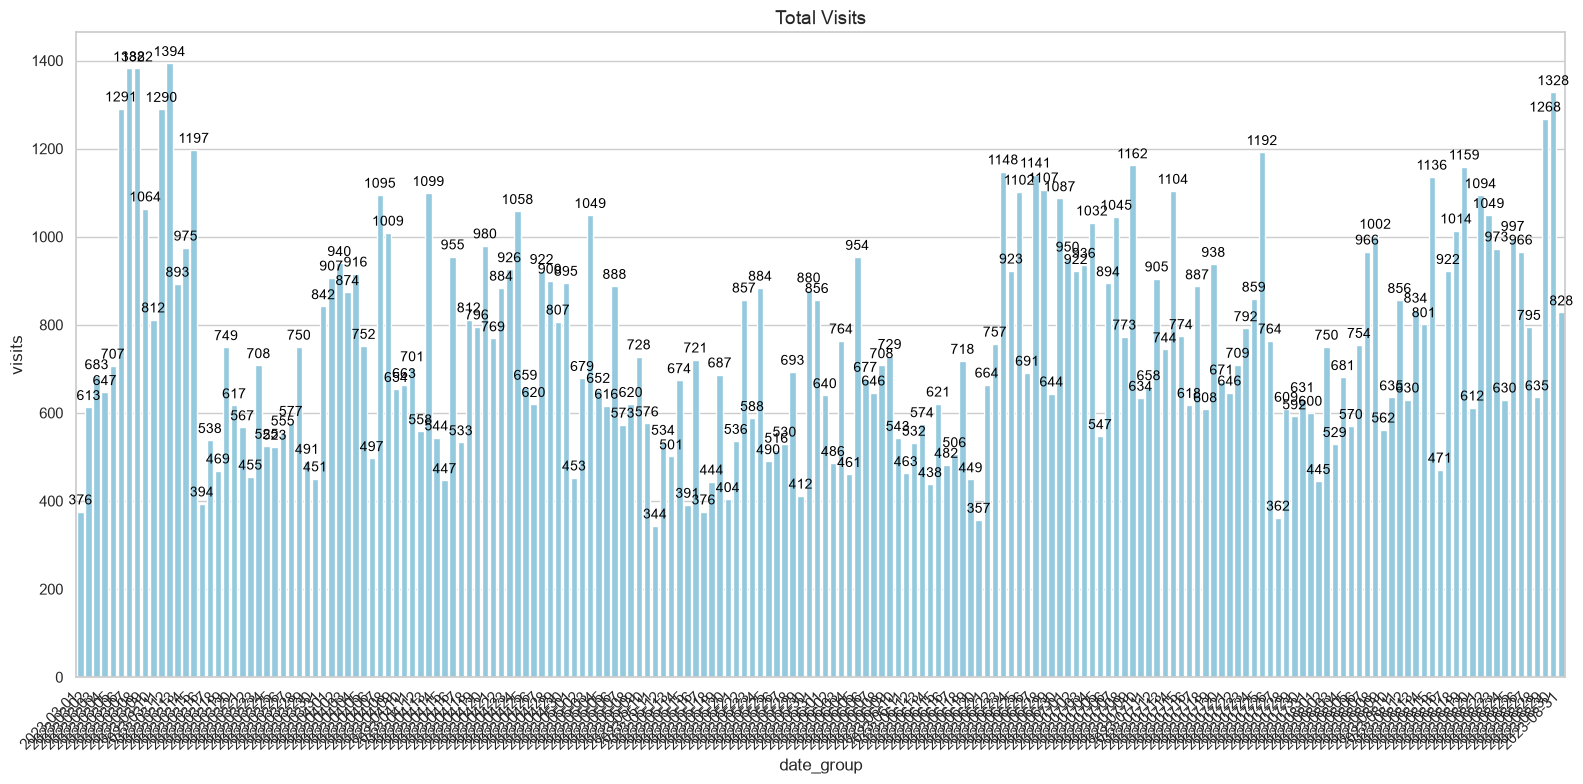

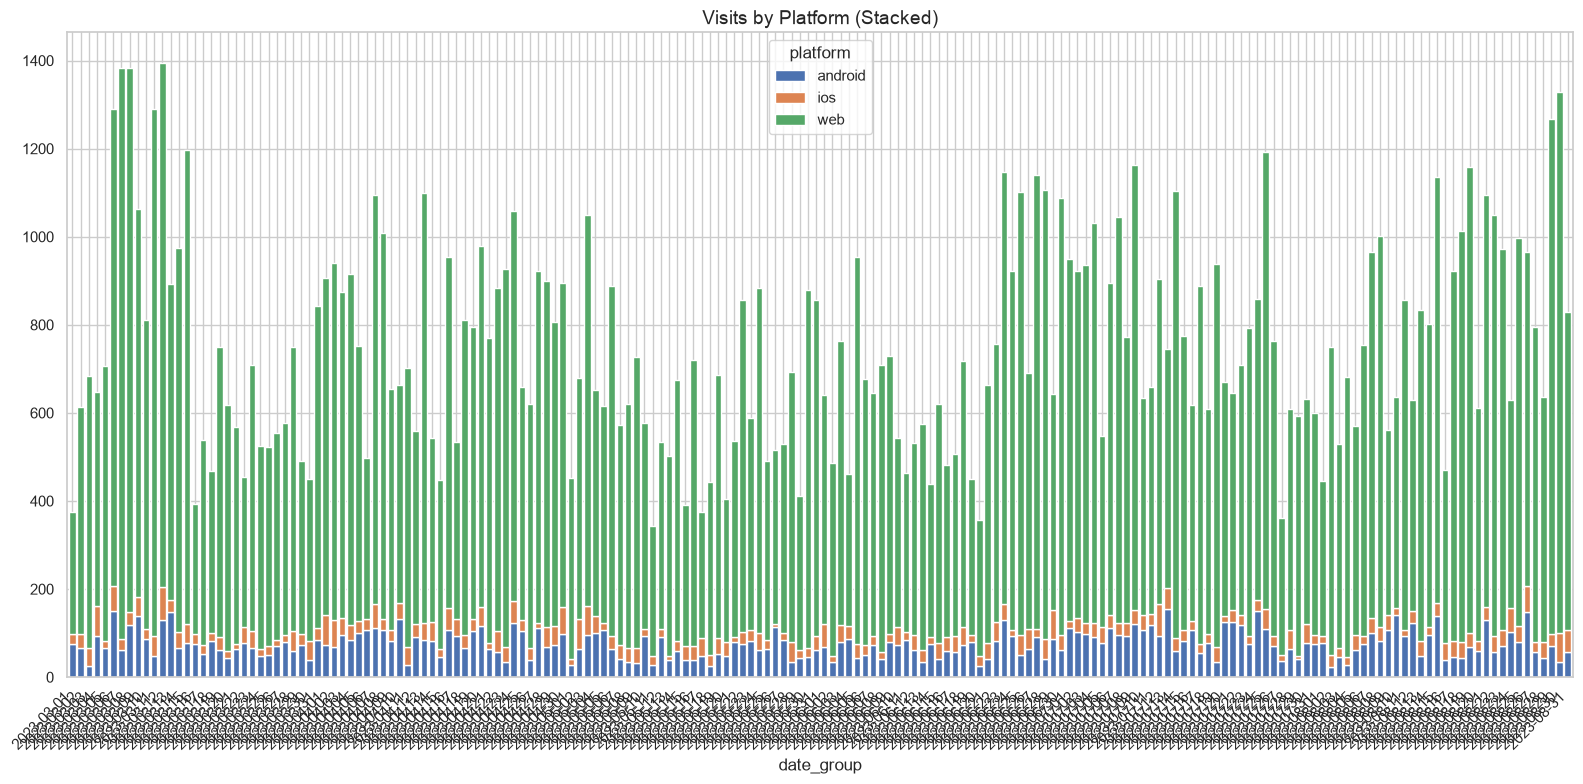

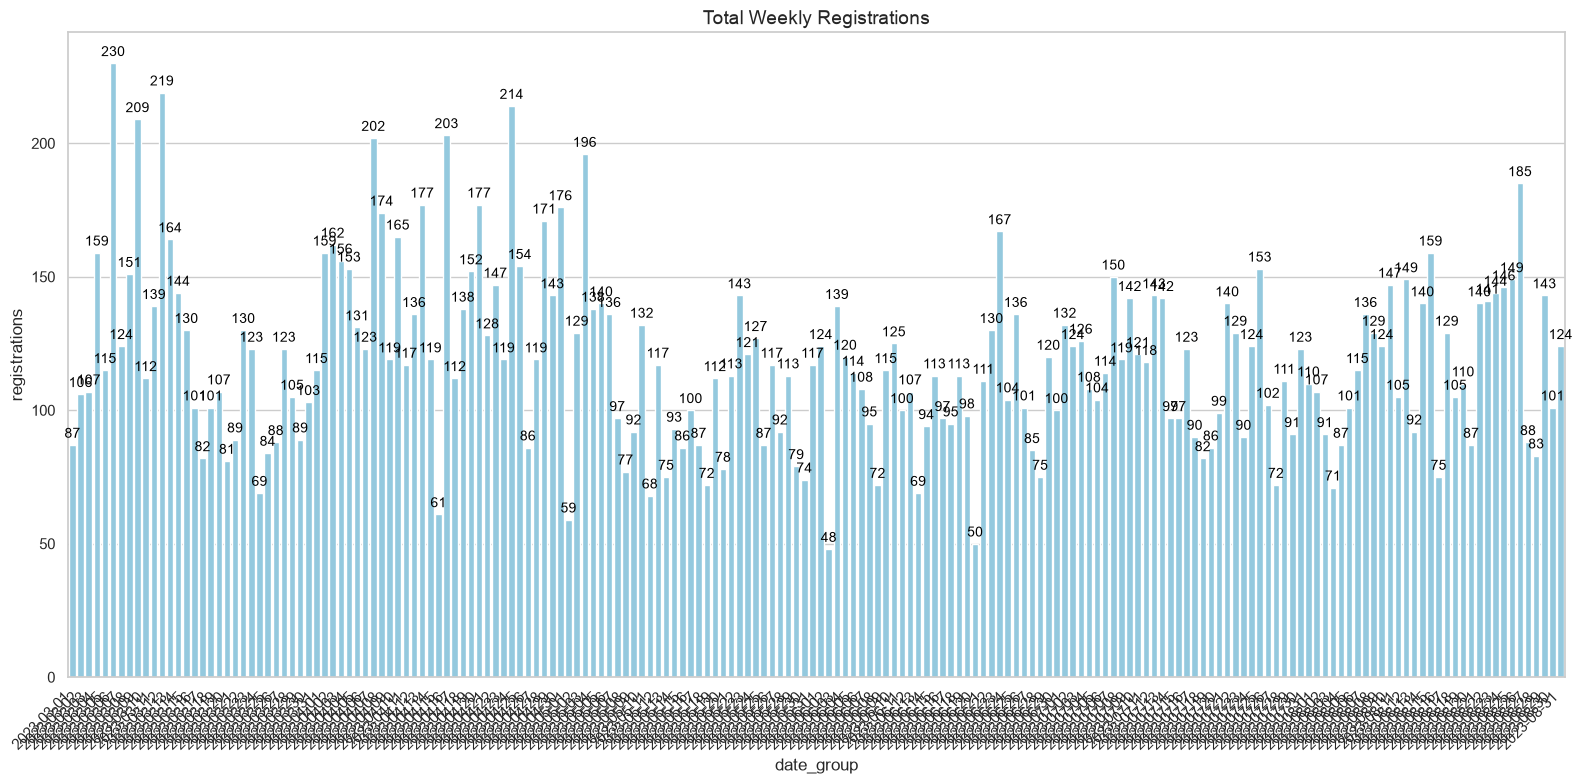

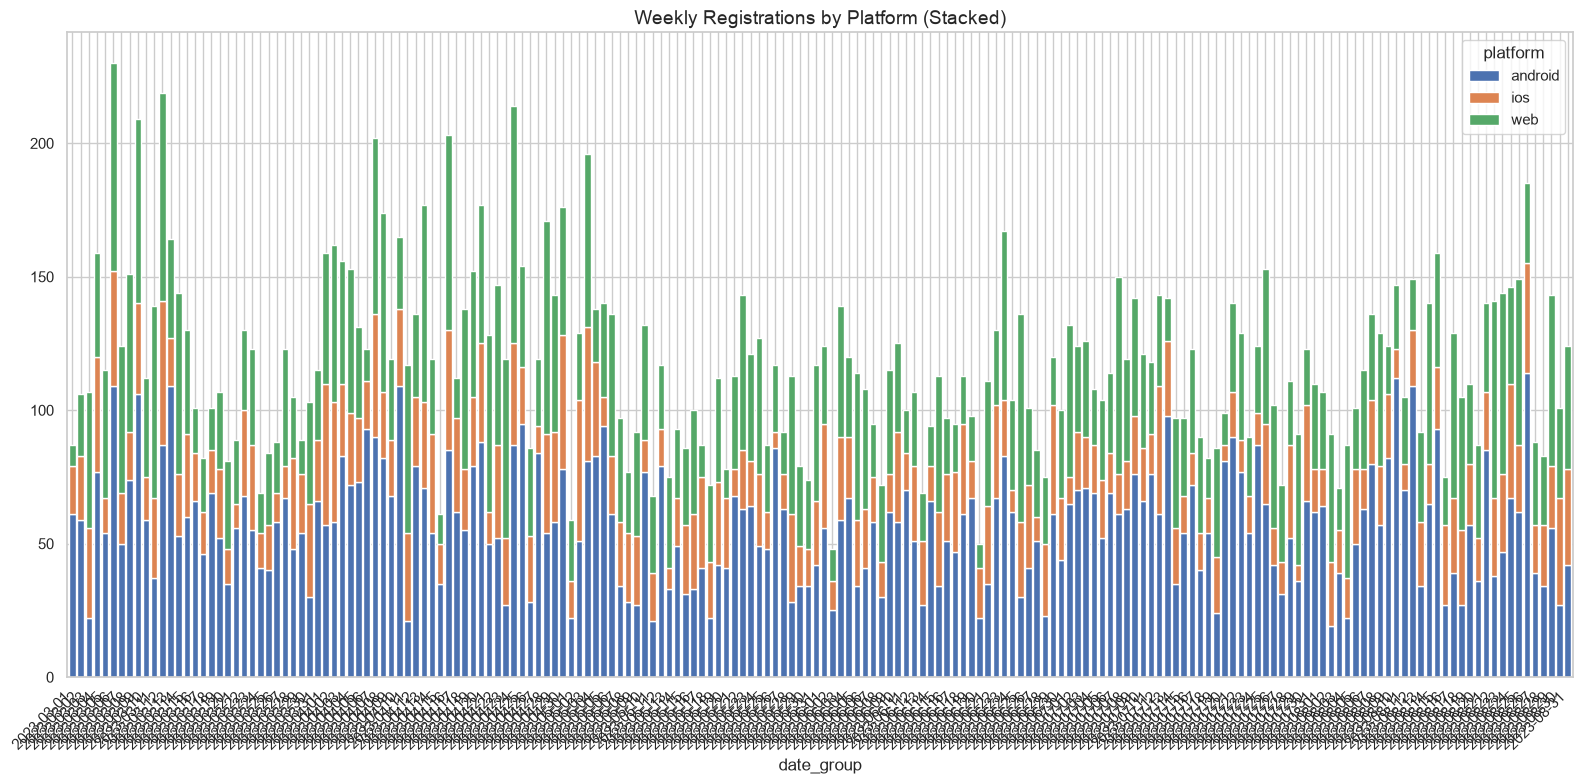

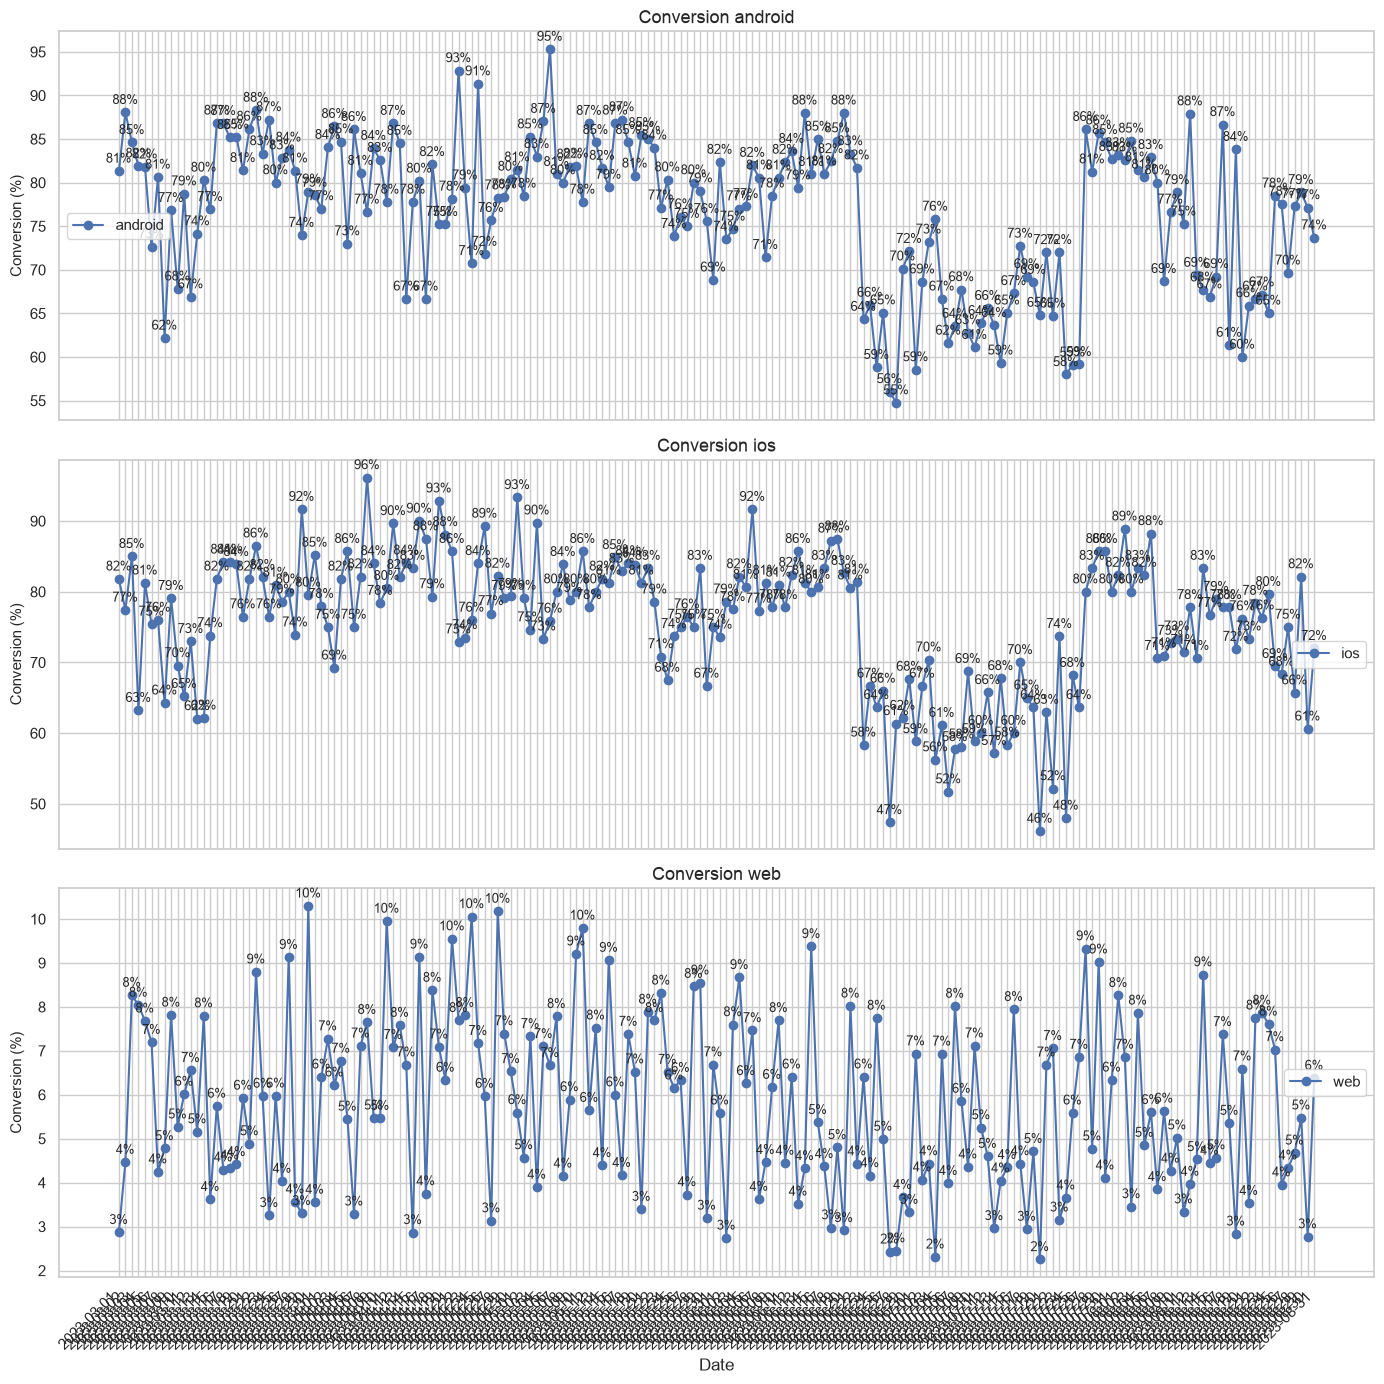

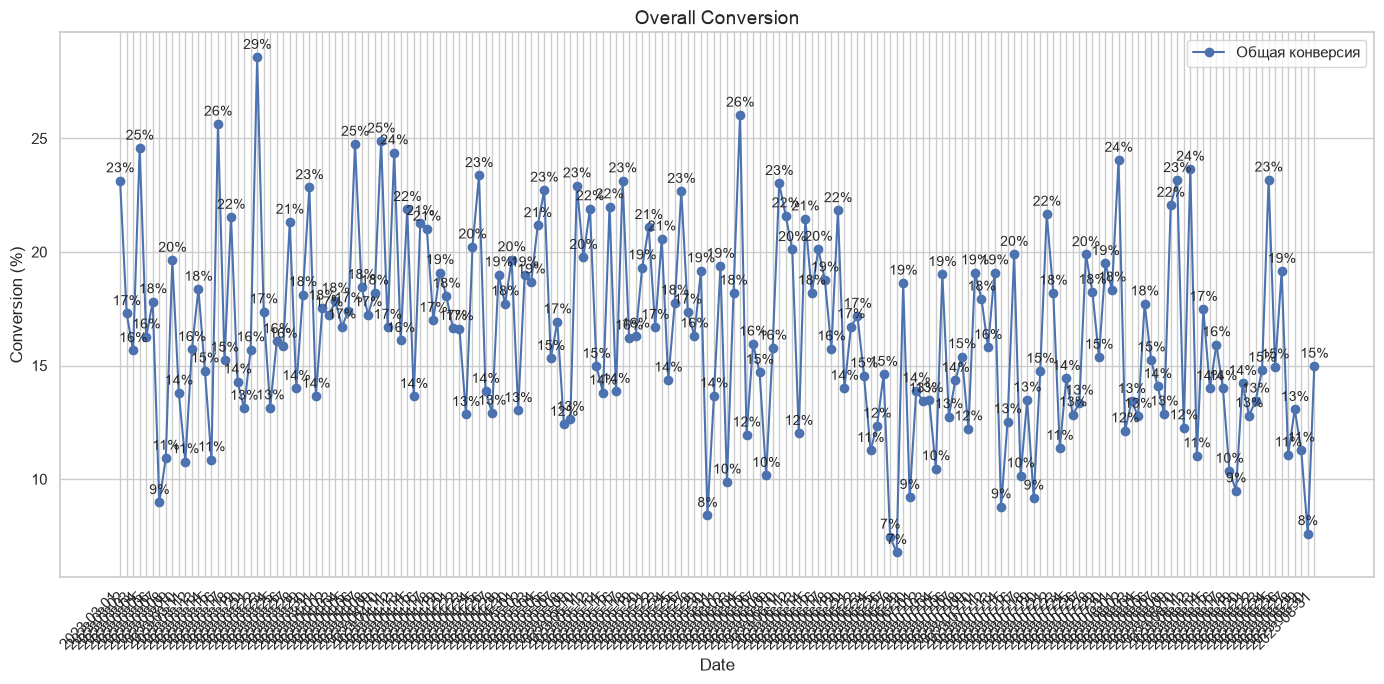

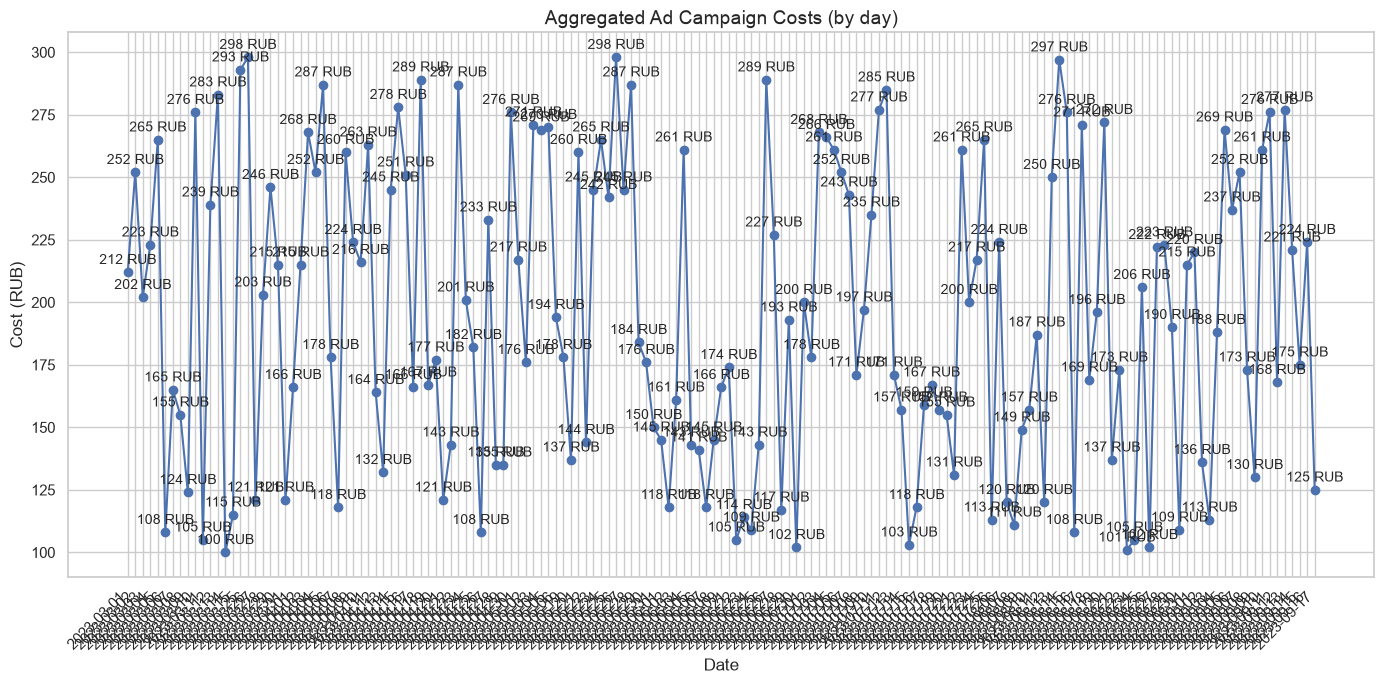

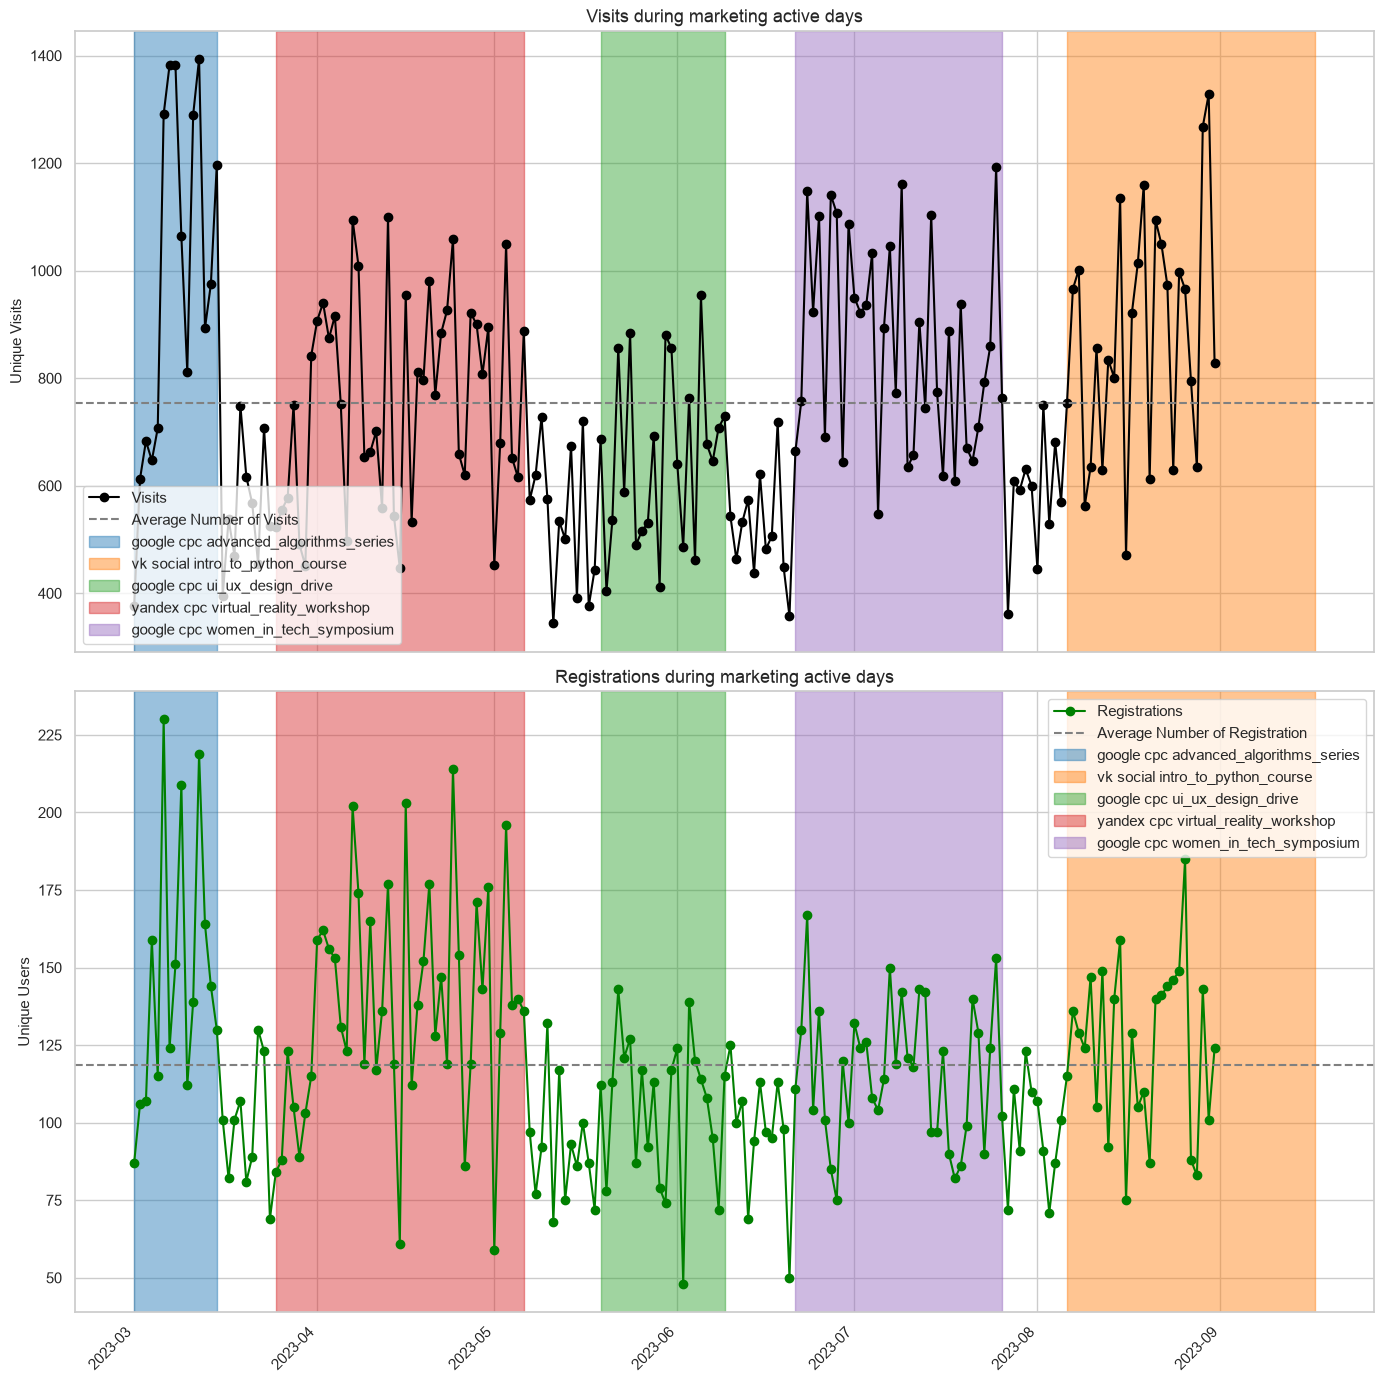

¡Todos los gráficos fueron generados y guardados en ./charts exitosamente!


In [8]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Crear el directorio ./charts si no existe
os.makedirs('./charts', exist_ok=True)
sns.set_theme(style="whitegrid")

# Asegurar columna de texto con la fecha (YYYY-MM-DD)
conversion_df['date_str'] = conversion_df['date_group'].dt.strftime('%Y-%m-%d')

# Preparar datos agregados diarios
daily_summary = conversion_df.groupby('date_str').agg({
    'visits': 'sum',
    'registrations': 'sum',
    'date_group': 'first'
}).reset_index().sort_values('date_group')

daily_summary['conversion'] = (daily_summary['registrations'] / daily_summary['visits']) * 100

# Tablas pivote usando fecha como string para evitar el error de freq
visits_pivot = conversion_df.pivot(index='date_str', columns='platform', values='visits').fillna(0)
regs_pivot = conversion_df.pivot(index='date_str', columns='platform', values='registrations').fillna(0)

# ==========================================
# 1. Gráfico: Visitas Totales
# ==========================================
plt.figure(figsize=(16, 8))
ax = sns.barplot(data=daily_summary, x='date_str', y='visits', color='skyblue')
plt.title('Total Visits', fontsize=14)
plt.xlabel('date_group', fontsize=12)
plt.ylabel('visits', fontsize=12)
plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    val = int(p.get_height())
    if val > 0:
        ax.annotate(str(val), (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.savefig('./charts/total_visits.png', dpi=300)
plt.show()

# ==========================================
# 2. Gráfico: Visitas por Plataforma (Apiladas)
# ==========================================
ax = visits_pivot.plot(kind='bar', stacked=True, figsize=(16, 8), width=0.8)
plt.title('Visits by Platform (Stacked)', fontsize=14)
plt.xlabel('date_group', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='platform')
plt.tight_layout()
plt.savefig('./charts/total_visits_by_platform.png', dpi=300)
plt.show()

# ==========================================
# 3. Gráfico: Registros Totales
# ==========================================
plt.figure(figsize=(16, 8))
ax = sns.barplot(data=daily_summary, x='date_str', y='registrations', color='skyblue')
plt.title('Total Weekly Registrations', fontsize=14)
plt.xlabel('date_group', fontsize=12)
plt.ylabel('registrations', fontsize=12)
plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    val = int(p.get_height())
    if val > 0:
        ax.annotate(str(val), (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.savefig('./charts/total_registrations.png', dpi=300)
plt.show()

# ==========================================
# 4. Gráfico: Registros por Plataforma (Apiladas)
# ==========================================
ax = regs_pivot.plot(kind='bar', stacked=True, figsize=(16, 8), width=0.8)
plt.title('Weekly Registrations by Platform (Stacked)', fontsize=14)
plt.xlabel('date_group', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='platform')
plt.tight_layout()
plt.savefig('./charts/total_registrations_by_platform.png', dpi=300)
plt.show()

# ==========================================
# 5. Gráfico: Conversión por Plataforma
# ==========================================
platforms = ['android', 'ios', 'web']
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

for i, plat in enumerate(platforms):
    plat_data = conversion_df[conversion_df['platform'] == plat].copy().sort_values('date_group')
    
    axes[i].plot(plat_data['date_str'], plat_data['conversion'], marker='o', label=plat)
    axes[i].set_title(f'Conversion {plat}', fontsize=13)
    axes[i].set_ylabel('Conversion (%)', fontsize=11)
    axes[i].legend(loc='center left' if plat == 'android' else 'center right')
    
    for x_idx, (idx_row, row) in enumerate(plat_data.iterrows()):
        axes[i].annotate(f"{int(round(row['conversion']))}%", 
                         (x_idx, row['conversion']),
                         textcoords="offset points", xytext=(0, 6), ha='center', fontsize=9)

plt.xlabel('Date', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('./charts/conversion_by_platforms.png', dpi=300)
plt.show()

# ==========================================
# 6. Gráfico: Conversión General
# ==========================================
plt.figure(figsize=(14, 7))
plt.plot(daily_summary['date_str'], daily_summary['conversion'], marker='o', label='Общая конверсия')
plt.title('Overall Conversion', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Conversion (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()

for x_idx, val in enumerate(daily_summary['conversion']):
    plt.annotate(f"{int(round(val))}%", (x_idx, val),
                 textcoords="offset points", xytext=(0, 6), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('./charts/conversion.png', dpi=300)
plt.show()

# ==========================================
# 7. Gráfico: Costos de Campañas Publicitarias
# ==========================================
ads_costs = ads_df.groupby('date_group')['cost'].sum().reset_index().sort_values('date_group')
ads_costs['date_str'] = ads_costs['date_group'].dt.strftime('%Y-%m-%d')

plt.figure(figsize=(14, 7))
plt.plot(ads_costs['date_str'], ads_costs['cost'], marker='o')
plt.title('Aggregated Ad Campaign Costs (by day)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cost (RUB)', fontsize=12)
plt.xticks(rotation=45, ha='right')

for x_idx, val in enumerate(ads_costs['cost']):
    plt.annotate(f"{val} RUB", (x_idx, val),
                 textcoords="offset points", xytext=(0, 6), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('./charts/ads_cost.png', dpi=300)
plt.show()

# ==========================================
# 8. Gráfico: Actividad durante Campañas
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 14), sharex=True)

campaign_groups = ads_df.groupby('utm_campaign').agg(
    source=('utm_source', 'first'),
    medium=('utm_medium', 'first'),
    start=('date_group', 'min'),
    end=('date_group', 'max')
).reset_index()

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Panel 1: Visitas
ax1.plot(daily_summary['date_group'], daily_summary['visits'], marker='o', color='black', label='Visits')
avg_visits = daily_summary['visits'].mean()
ax1.axhline(avg_visits, color='grey', linestyle='--', label='Average Number of Visits')
ax1.set_title('Visits during marketing active days', fontsize=13)
ax1.set_ylabel('Unique Visits', fontsize=11)

# Panel 2: Registros
ax2.plot(daily_summary['date_group'], daily_summary['registrations'], marker='o', color='green', label='Registrations')
avg_regs = daily_summary['registrations'].mean()
ax2.axhline(avg_regs, color='grey', linestyle='--', label='Average Number of Registration')
ax2.set_title('Registrations during marketing active days', fontsize=13)
ax2.set_ylabel('Unique Users', fontsize=11)

for idx, row in campaign_groups.iterrows():
    c_label = f"{row['source']} {row['medium']} {row['utm_campaign']}"
    col = colors[idx % len(colors)]
    ax1.axvspan(row['start'], row['end'], alpha=0.45, color=col, label=c_label)
    ax2.axvspan(row['start'], row['end'], alpha=0.45, color=col, label=c_label)

ax1.legend(loc='lower left')
ax2.legend(loc='upper right')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('./charts/activity_during_marketing_campaign.png', dpi=300)
plt.show()

print("¡Todos los gráficos fueron generados y guardados en ./charts exitosamente!")

In [9]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# 1. Crear directorio para guardar gráficos
os.makedirs('./charts', exist_ok=True)
sns.set_theme(style="whitegrid")

# 2. Cargar variables de entorno desde .env
load_dotenv()
API_URL = os.getenv('API_URL', 'https://data-charts-api.hexlet.app')
DATE_BEGIN = os.getenv('DATE_BEGIN', '2023-03-01')
DATE_END = os.getenv('DATE_END', '2023-09-01')

# 3. Consultar datos en la API
params = {'begin': DATE_BEGIN, 'end': DATE_END}
response_visits = requests.get(f'{API_URL}/visits', params=params)
response_regs = requests.get(f'{API_URL}/registrations', params=params)

df_api_visits = pd.DataFrame(response_visits.json())
df_api_regs = pd.DataFrame(response_regs.json())

# 4. Limpieza y preparación de visitas y registros
df_api_visits['datetime'] = pd.to_datetime(df_api_visits['datetime'])
df_api_regs['datetime'] = pd.to_datetime(df_api_regs['datetime'])

# Excluir bots
mask_no_bot = (
    ~df_api_visits['user_agent'].str.contains('bot', case=False, na=False) & 
    (df_api_visits['platform'] != 'bot')
)
df_visits_clean = df_api_visits[mask_no_bot].copy()
df_visits_clean = df_visits_clean.sort_values('datetime').drop_duplicates(subset=['visit_id'], keep='last')

df_visits_clean['date_group'] = df_visits_clean['datetime'].dt.normalize()
df_api_regs['date_group'] = df_api_regs['datetime'].dt.normalize()

# 5. Agrupar conversiones por fecha y plataforma
visits_grouped = df_visits_clean.groupby(['date_group', 'platform']).size().reset_index(name='visits')
regs_grouped = df_api_regs.groupby(['date_group', 'platform']).size().reset_index(name='registrations')

conversion_df = pd.merge(visits_grouped, regs_grouped, on=['date_group', 'platform'], how='inner')
conversion_df['conversion'] = (conversion_df['registrations'] / conversion_df['visits']) * 100
conversion_df = conversion_df.sort_values(by=['date_group', 'platform']).reset_index(drop=True)

# Guardar conversion.json
conversion_df.to_json("./conversion.json")

# 6. Integrar campañas publicitarias (ads.csv)
ads_df = pd.read_csv('./ads.csv')
ads_df['date'] = pd.to_datetime(ads_df['date'])
ads_df['date_group'] = ads_df['date'].dt.normalize()

ads_grouped = ads_df.groupby('date_group').agg({
    'cost': 'sum',
    'utm_campaign': 'first'
}).reset_index()

daily_conversion = conversion_df.groupby('date_group').agg({
    'visits': 'sum',
    'registrations': 'sum'
}).reset_index()

final_ads_df = pd.merge(daily_conversion, ads_grouped, on='date_group', how='left')
final_ads_df['cost'] = final_ads_df['cost'].fillna(0).astype(int)
final_ads_df['utm_campaign'] = final_ads_df['utm_campaign'].fillna('none')
final_ads_df = final_ads_df[['date_group', 'visits', 'registrations', 'cost', 'utm_campaign']].sort_values('date_group').reset_index(drop=True)

# Guardar ads.json
final_ads_df.to_json("./ads.json")

# 7. Preparación para gráficos
conversion_df['date_str'] = conversion_df['date_group'].dt.strftime('%Y-%m-%d')
daily_summary = conversion_df.groupby('date_str').agg({
    'visits': 'sum',
    'registrations': 'sum',
    'date_group': 'first'
}).reset_index().sort_values('date_group')
daily_summary['conversion'] = (daily_summary['registrations'] / daily_summary['visits']) * 100

visits_pivot = conversion_df.pivot(index='date_str', columns='platform', values='visits').fillna(0)
regs_pivot = conversion_df.pivot(index='date_str', columns='platform', values='registrations').fillna(0)

# Gráfico 1: Visitas Totales
plt.figure(figsize=(16, 8))
ax = sns.barplot(data=daily_summary, x='date_str', y='visits', color='skyblue')
plt.title('Total Visits', fontsize=14)
plt.xlabel('date_group', fontsize=12)
plt.ylabel('visits', fontsize=12)
plt.xticks(rotation=45, ha='right')
for p in ax.patches:
    val = int(p.get_height())
    if val > 0:
        ax.annotate(str(val), (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.savefig('./charts/total_visits.png', dpi=300)
plt.close()

# Gráfico 2: Visitas por Plataforma (Stacked)
visits_pivot.plot(kind='bar', stacked=True, figsize=(16, 8), width=0.8)
plt.title('Visits by Platform (Stacked)', fontsize=14)
plt.xlabel('date_group', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='platform')
plt.tight_layout()
plt.savefig('./charts/total_visits_by_platform.png', dpi=300)
plt.close()

# Gráfico 3: Registros Totales
plt.figure(figsize=(16, 8))
ax = sns.barplot(data=daily_summary, x='date_str', y='registrations', color='skyblue')
plt.title('Total Weekly Registrations', fontsize=14)
plt.xlabel('date_group', fontsize=12)
plt.ylabel('registrations', fontsize=12)
plt.xticks(rotation=45, ha='right')
for p in ax.patches:
    val = int(p.get_height())
    if val > 0:
        ax.annotate(str(val), (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, color='black', xytext=(0, 3), textcoords='offset points')
plt.tight_layout()
plt.savefig('./charts/total_registrations.png', dpi=300)
plt.close()

# Gráfico 4: Registros por Plataforma (Stacked)
regs_pivot.plot(kind='bar', stacked=True, figsize=(16, 8), width=0.8)
plt.title('Weekly Registrations by Platform (Stacked)', fontsize=14)
plt.xlabel('date_group', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='platform')
plt.tight_layout()
plt.savefig('./charts/total_registrations_by_platform.png', dpi=300)
plt.close()

# Gráfico 5: Conversión por Plataforma
platforms = ['android', 'ios', 'web']
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)
for i, plat in enumerate(platforms):
    plat_data = conversion_df[conversion_df['platform'] == plat].copy().sort_values('date_group')
    axes[i].plot(plat_data['date_str'], plat_data['conversion'], marker='o', label=plat)
    axes[i].set_title(f'Conversion {plat}', fontsize=13)
    axes[i].set_ylabel('Conversion (%)', fontsize=11)
    axes[i].legend(loc='center left' if plat == 'android' else 'center right')
    for x_idx, (idx_row, row) in enumerate(plat_data.iterrows()):
        axes[i].annotate(f"{int(round(row['conversion']))}%", 
                         (x_idx, row['conversion']),
                         textcoords="offset points", xytext=(0, 6), ha='center', fontsize=9)
plt.xlabel('Date', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('./charts/conversion_by_platforms.png', dpi=300)
plt.close()

# Gráfico 6: Conversión General
plt.figure(figsize=(14, 7))
plt.plot(daily_summary['date_str'], daily_summary['conversion'], marker='o', label='Общая конверсия')
plt.title('Overall Conversion', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Conversion (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
for x_idx, val in enumerate(daily_summary['conversion']):
    plt.annotate(f"{int(round(val))}%", (x_idx, val),
                 textcoords="offset points", xytext=(0, 6), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('./charts/conversion.png', dpi=300)
plt.close()

# Gráfico 7: Costos de Campañas
ads_costs = ads_df.groupby('date_group')['cost'].sum().reset_index().sort_values('date_group')
ads_costs['date_str'] = ads_costs['date_group'].dt.strftime('%Y-%m-%d')
plt.figure(figsize=(14, 7))
plt.plot(ads_costs['date_str'], ads_costs['cost'], marker='o')
plt.title('Aggregated Ad Campaign Costs (by day)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cost (RUB)', fontsize=12)
plt.xticks(rotation=45, ha='right')
for x_idx, val in enumerate(ads_costs['cost']):
    plt.annotate(f"{val} RUB", (x_idx, val),
                 textcoords="offset points", xytext=(0, 6), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('./charts/ads_cost.png', dpi=300)
plt.close()

# Gráfico 8: Actividad durante Campañas
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 14), sharex=True)
campaign_groups = ads_df.groupby('utm_campaign').agg(
    source=('utm_source', 'first'),
    medium=('utm_medium', 'first'),
    start=('date_group', 'min'),
    end=('date_group', 'max')
).reset_index()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

ax1.plot(daily_summary['date_group'], daily_summary['visits'], marker='o', color='black', label='Visits')
ax1.axhline(daily_summary['visits'].mean(), color='grey', linestyle='--', label='Average Number of Visits')
ax1.set_title('Visits during marketing active days', fontsize=13)
ax1.set_ylabel('Unique Visits', fontsize=11)

ax2.plot(daily_summary['date_group'], daily_summary['registrations'], marker='o', color='green', label='Registrations')
ax2.axhline(daily_summary['registrations'].mean(), color='grey', linestyle='--', label='Average Number of Registration')
ax2.set_title('Registrations during marketing active days', fontsize=13)
ax2.set_ylabel('Unique Users', fontsize=11)

for idx, row in campaign_groups.iterrows():
    c_label = f"{row['source']} {row['medium']} {row['utm_campaign']}"
    col = colors[idx % len(colors)]
    ax1.axvspan(row['start'], row['end'], alpha=0.45, color=col, label=c_label)
    ax2.axvspan(row['start'], row['end'], alpha=0.45, color=col, label=c_label)

ax1.legend(loc='lower left')
ax2.legend(loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('./charts/activity_during_marketing_campaign.png', dpi=300)
plt.close()

print("¡Todo el flujo se ejecutó, los JSONs se guardaron y los gráficos se generaron en ./charts exitosamente!")

/var/folders/js/pn10sr2558b2pyg3k26w7czw0000gn/T/ipykernel_2169/263402876.py:51: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  conversion_df.to_json("./conversion.json")
/var/folders/js/pn10sr2558b2pyg3k26w7czw0000gn/T/ipykernel_2169/263402876.py:74: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  final_ads_df.to_json("./ads.json")


¡Todo el flujo se ejecutó, los JSONs se guardaron y los gráficos se generaron en ./charts exitosamente!
